In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
df.shape

Mounted at /content/drive


(284807, 31)

In [2]:
df.shape

(284807, 31)

In [3]:
from sklearn.utils.class_weight import compute_class_weight

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Time and Amount Visualization

/tmp/ipython-input-2700368311.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(amount_val, ax=ax[0], color='r')
/tmp/ipython-input-2700368311.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(time_val, ax=ax[1], color='b')


(0.0, 172792.0)

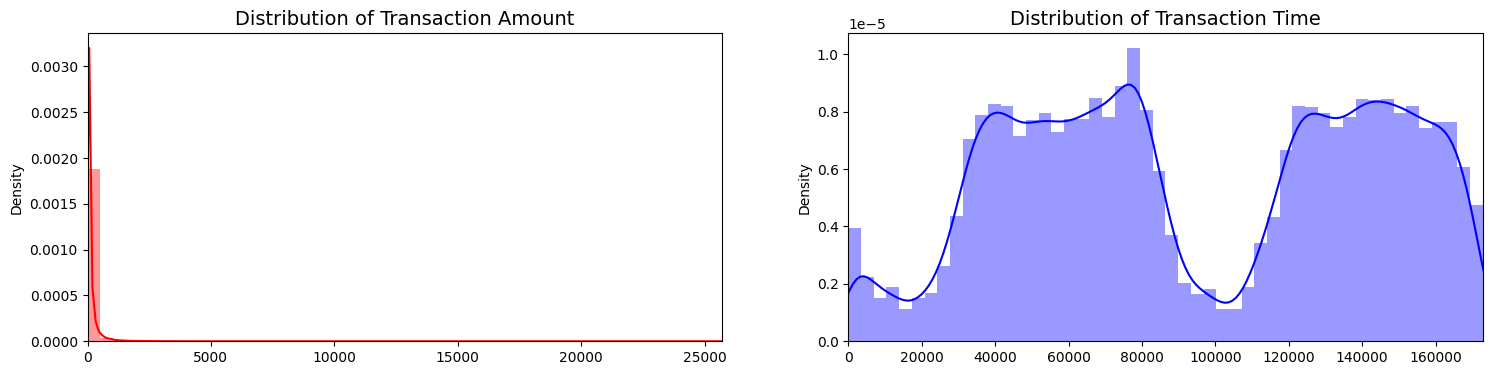

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))
amount_val = df['Amount'].values
time_val = df['Time'].values
sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])


# Data Scaling - Standard Scaler

In [6]:
from sklearn.preprocessing import StandardScaler, RobustScaler
std_scaler = StandardScaler()
rob_scaler = RobustScaler() # odporniejszy na wartosci odstajace

In [7]:
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)

In [8]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1,  inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [9]:
df.shape

(284807, 31)

In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections

# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings

In [11]:
X_real = df.drop('Class', axis=1)
y_real = df['Class']

In [12]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

In [13]:
X_val_real, X_test_real, y_val_real, y_test_real = train_test_split(X_test_real, y_test_real, test_size=0.3, random_state=42)

In [14]:
X_train_real.shape, X_val_real.shape, X_test_real.shape

((199364, 30), (59810, 30), (25633, 30))

# Random Under Sampling

- We have to balace our data because when model learn on imbalaced data it might be predict class which have more representants in our data (if we have 90 % class 0 and 10 % class 1 then model show more prediction of class 0)

In [15]:
X_train_real.shape, X_test_real.shape, y_train_real.shape

((199364, 30), (25633, 30), (199364,))

In [16]:
temp = pd.concat([X_train_real, y_train_real], axis=1)
temp.shape

(199364, 31)

In [17]:
temp.shape

(199364, 31)

In [18]:
temp =temp.sample(frac=1)
temp.shape

(199364, 31)

In [19]:
temp = temp.sample(frac=1)
fraud_df = temp.loc[df['Class'] == 1]
fraud_df.shape
non_fraud_df = df.loc[df['Class'] == 0][:356]
normal_distributed_df = pd.concat([fraud_df, non_fraud_df])
normal_distributed_df.shape

(712, 31)

In [20]:
new_df = normal_distributed_df.sample(frac=1, random_state=42)
new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
150,12.795221,-0.993891,-1.640014,-0.479831,1.613630,2.997979,-3.803788,5.051812,3.315254,-0.303785,...,0.124193,-0.367933,0.641891,-0.405779,-1.268700,0.494090,0.610967,0.608993,-0.410034,0
38,-0.020541,-0.994643,0.996370,-0.122589,0.546819,0.706580,0.134560,1.156995,-0.294561,0.407429,...,-0.203461,-0.076302,0.108867,0.162231,-0.575624,0.109795,0.373813,0.050552,0.005106,0
10801,-0.293440,-0.778827,-14.474437,6.503185,-17.712632,11.270352,-4.150142,-3.372098,-16.535807,-1.443947,...,1.101250,-2.475962,0.342391,-3.564508,-0.818140,0.153408,0.755079,2.706566,-0.992916,1
223572,-0.293440,0.690116,-2.729482,3.312495,-4.242710,5.036985,-0.376561,-1.532462,-3.449159,1.856839,...,0.164288,0.727415,-0.301432,-0.502433,-0.462309,0.510683,0.046665,0.514646,0.140999,1
81,-0.214211,-0.994373,1.147369,0.059035,0.263632,1.211023,-0.044096,0.301067,-0.132960,0.227885,...,-0.255924,-0.087813,-0.110756,-0.097771,-0.323374,0.633279,-0.305328,0.027394,-0.000580,0


In [21]:
print(new_df['Class'].value_counts() / len(new_df))

Class
0    0.5
1    0.5
Name: count, dtype: float64


/tmp/ipython-input-1301005573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=new_df, palette=colors)


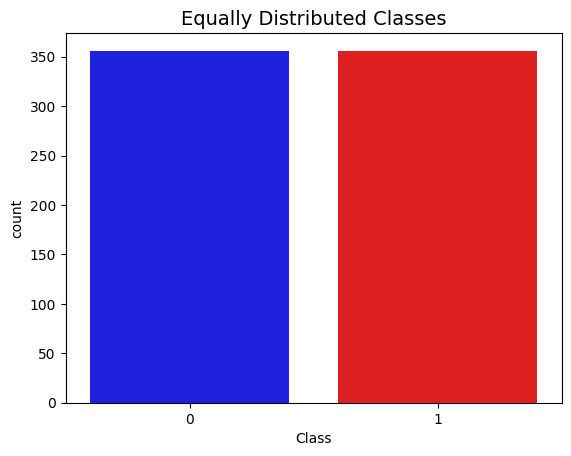

In [22]:
colors = ['blue', 'red']
sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

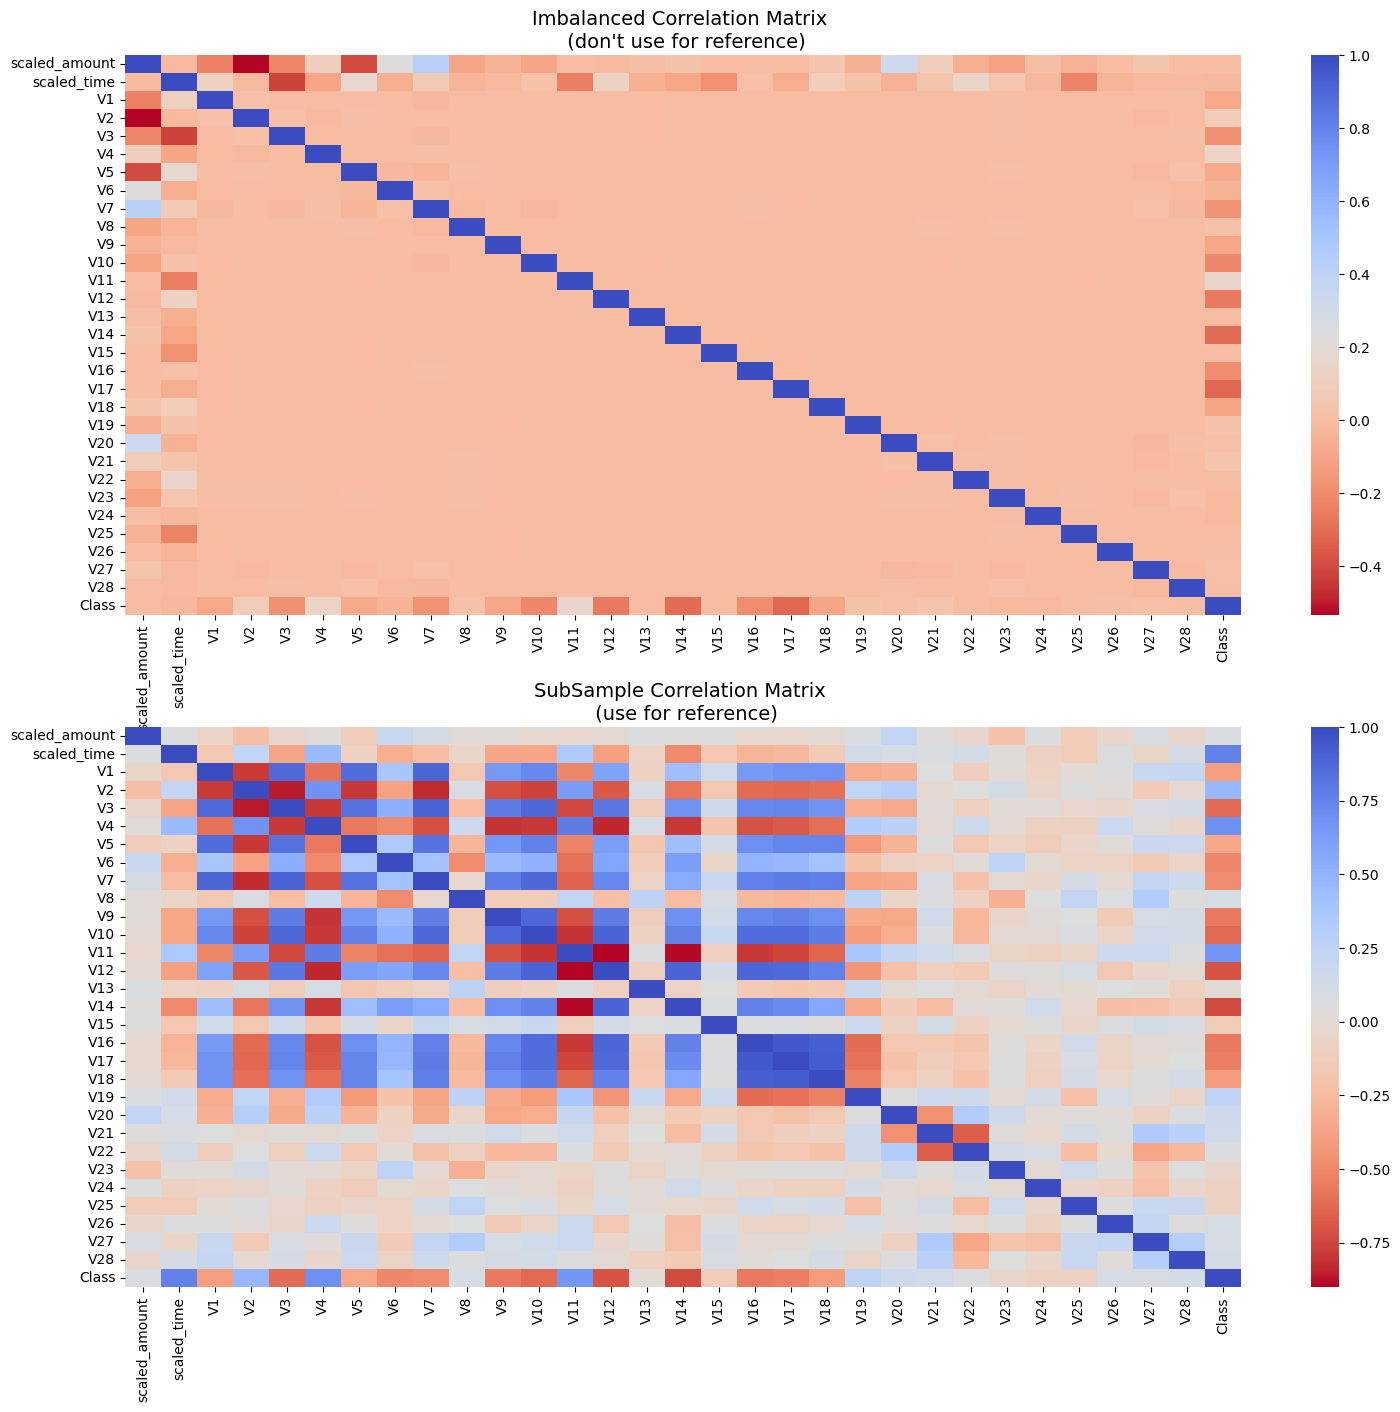

In [23]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 16))
corr = temp.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()


- We are looking for the highest positive and negative correlations with target - Class . The next step we will remove outliers in this categories which have this highest correlation with target . This step might be improve accuracy of our future models.

/tmp/ipython-input-1370678400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V17', data=new_df, palette=colors, ax=axes[0])
/tmp/ipython-input-1370678400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
/tmp/ipython-input-1370678400.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
/tmp/ipython-input-1370678400.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

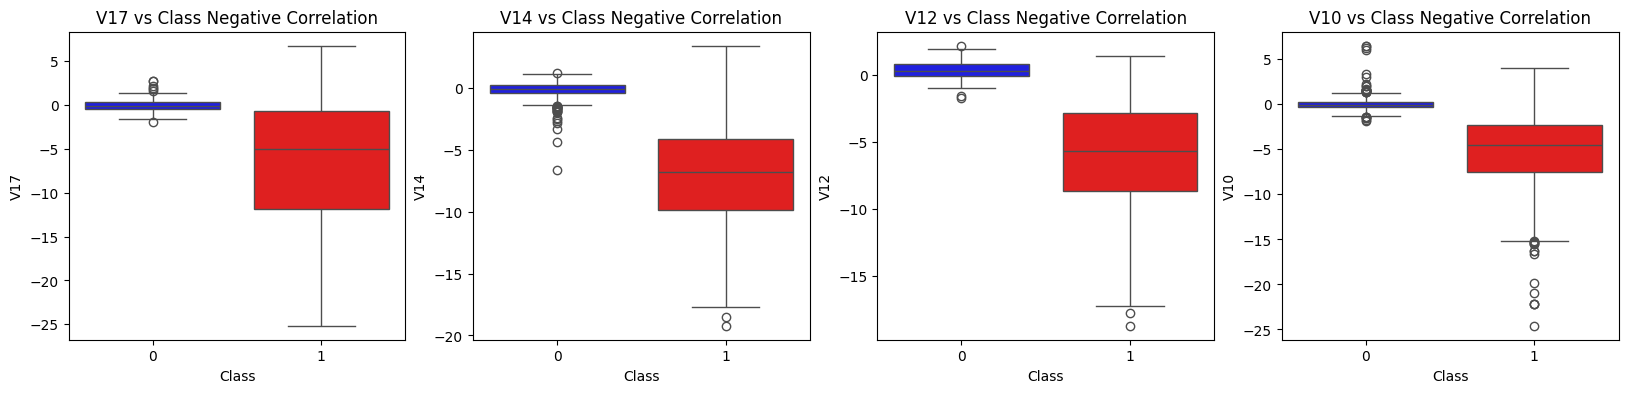

In [24]:
f, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.boxplot(x='Class', y='V17', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')
plt.show()


/tmp/ipython-input-4031377041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
/tmp/ipython-input-4031377041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
/tmp/ipython-input-4031377041.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
/tmp/ipython-input-4031377041.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

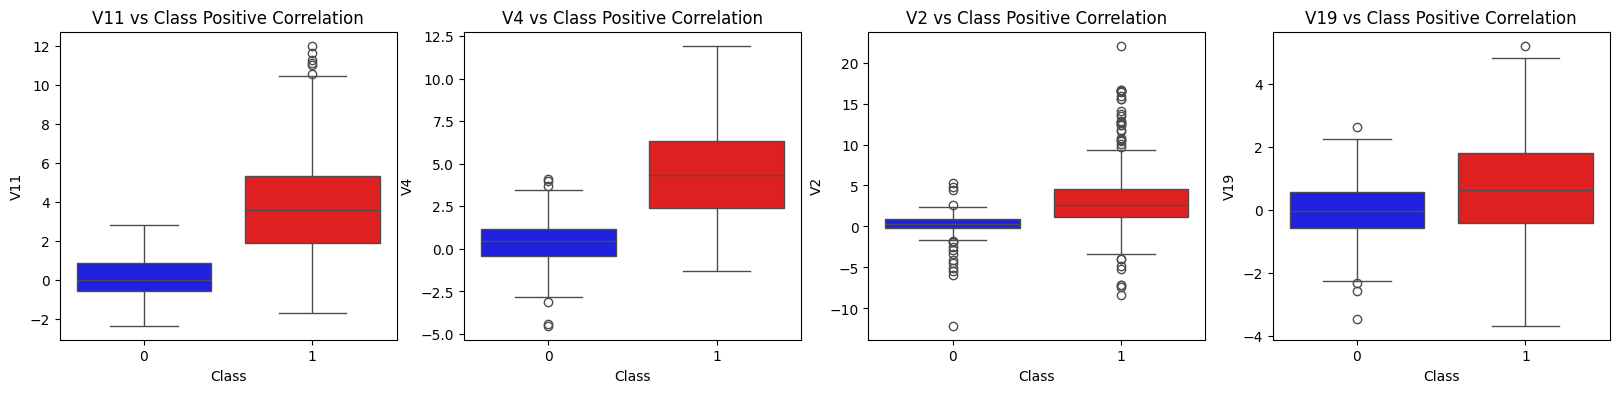

In [25]:
f, axes = plt.subplots(1, 4, figsize=(20,4))
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')
plt.show()


In [26]:
from scipy.stats import norm

/tmp/ipython-input-1341308514.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v14_fraud_dist, ax=ax1, fit=norm, color='red')
/tmp/ipython-input-1341308514.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
/tmp/ipython-input-1341308514.py:9:

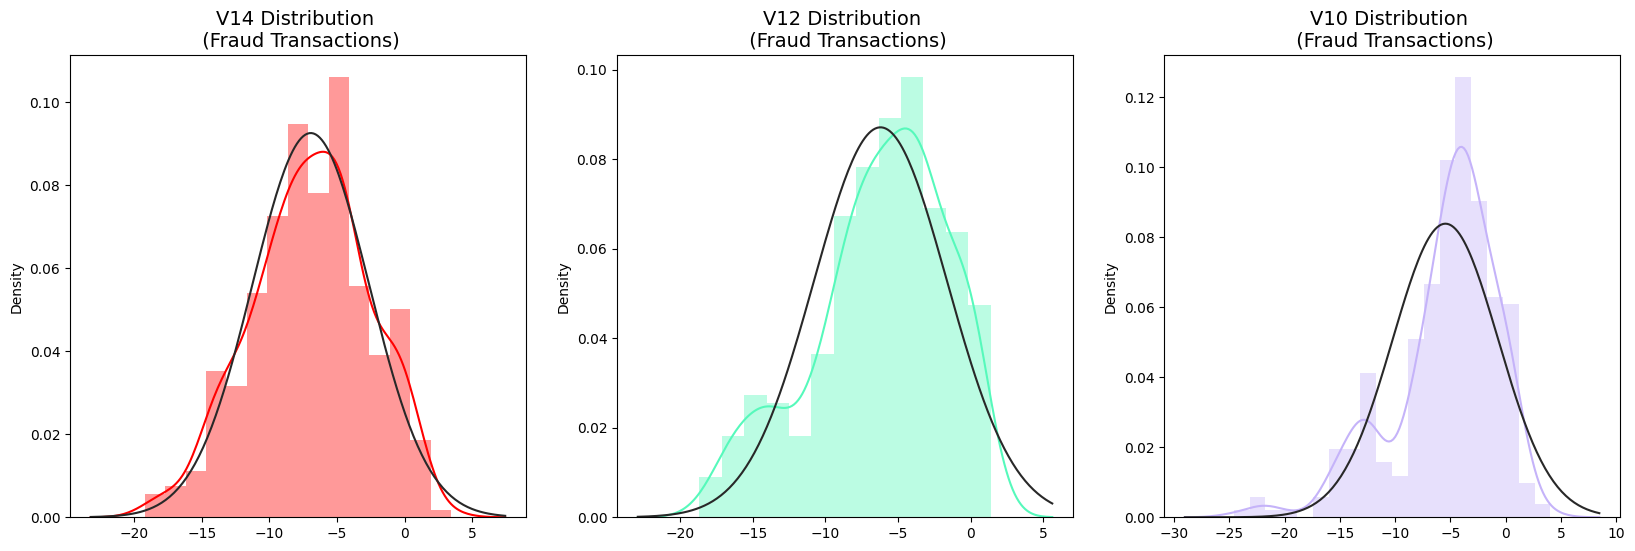

In [27]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist, ax=ax1, fit=norm, color='red')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)
v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)
v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist,ax=ax3, fit=norm, color='#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)
plt.show()

# Remove outliers

- it help in future prediction to get better results

In [28]:
# in negative correlation
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
v14_iqr = q75 - q25
v14_cut_off = 1.5 * v14_iqr
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
len(outliers)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25
v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)

# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25
v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)

/tmp/ipython-input-549770930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V14', data=new_df, palette=colors, ax=ax1)
/tmp/ipython-input-549770930.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V12', data=new_df, palette=colors, ax=ax2)
/tmp/ipython-input-549770930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V10', data=new_df, palette=colors, ax=ax3)


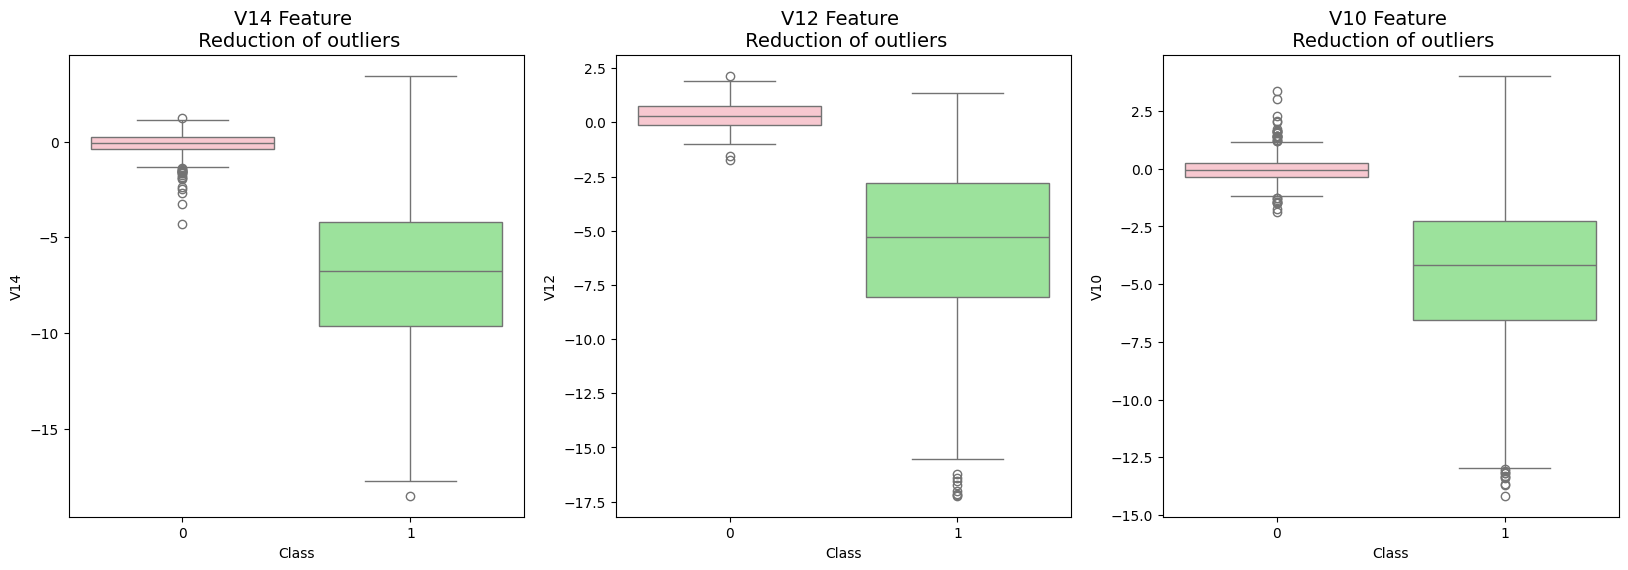

In [29]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
colors = ['pink', 'lightgreen']
sns.boxplot(x='Class', y='V14', data=new_df, palette=colors, ax=ax1)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
sns.boxplot(x='Class', y='V12', data=new_df, palette=colors, ax=ax2)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
sns.boxplot(x='Class', y='V10', data=new_df, palette=colors, ax=ax3)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
plt.show()

In [30]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)

In [31]:
X.shape, y.shape

((685, 30), (685,))

In [32]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [33]:
#X_train_u, X_val_u, y_train_u, y_val_u = train_test_split(X, y, test_size=0.2, random_state=42)
#X_val_u, X_test_u, y_val_u, y_test_u = train_test_split(X_val_u_, y_val_u_, test_size=0.3, random_state=42)

In [34]:
#X_train_u.shape, X_val_u.shape

In [35]:
#y_val_u.value_counts()

In [36]:
#X_train_u.shape, X_val_u.shape

In [37]:
y.value_counts()

,count
Class,
0,352
1,333


In [38]:
y_val_real.value_counts()

,count
Class,
0,59705
1,105


This area under the Precision-Recall curve. A very important metric for unbalanced data, as it shows how well the model detects the rare class.
In this case, it poorly detects class 1 due to the few training data cases after the division Under Sampling method.



- measures the average recall for each class. Good for unbalanced class problem

In [39]:

from sklearn.metrics import confusion_matrix

In [40]:
from imblearn.over_sampling import SMOTE
from collections import Counter
sm = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = sm.fit_resample(X_train_real, y_train_real)
print("Po SMOTE:", Counter(y_res))


Po SMOTE: Counter({0: 199008, 1: 199008})


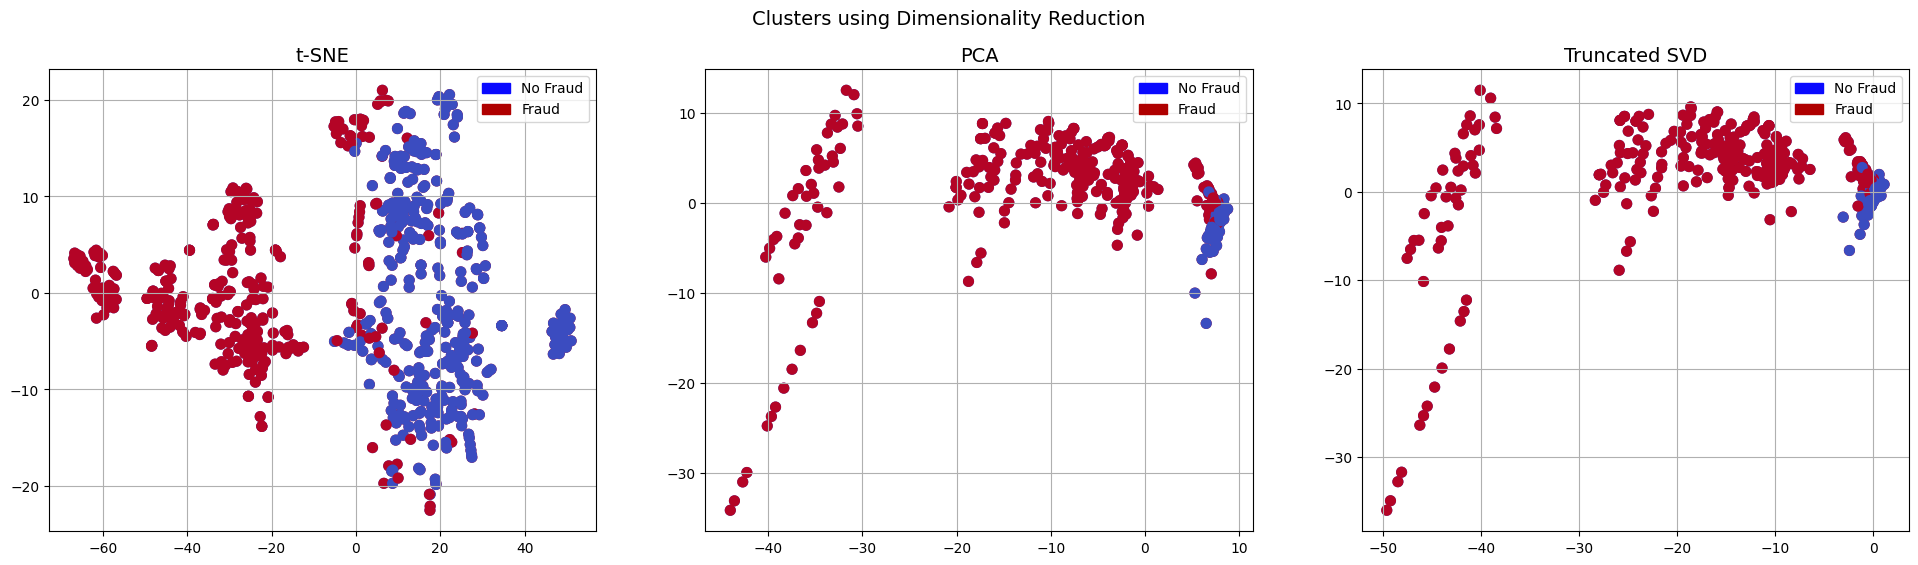

In [41]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)
blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])


plt.show()

In [42]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [43]:
X.shape, y.shape

((685, 30), (685,))

In [44]:
y.value_counts()

,count
Class,
0,352
1,333


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [47]:
classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

In [48]:
from sklearn.model_selection import cross_val_score
for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f"{key}:  {round(np.mean(training_score) * 100, 2)} %")

LogisiticRegression:  97.45 %
KNearest:  94.71 %
Support Vector Classifier:  95.26 %
DecisionTreeClassifier:  99.82 %


In [49]:
from sklearn.model_selection import GridSearchCV
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']})

In [50]:
log_reg = grid_log_reg.best_estimator_
log_reg

LogisticRegression(C=10)

In [51]:
knears_params = {"n_neighbors": list(range(2, 5, 1)),  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)
knears_neighbors = grid_knears.best_estimator_

In [52]:
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)
svc = grid_svc.best_estimator_

In [53]:
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)), "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)
tree_clf = grid_tree.best_estimator_

In [54]:
from sklearn.model_selection import cross_val_score
log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)


In [55]:
print(f'{round(log_reg_score.mean(), 2) * 100} %')

99.0 %


In [56]:
linear_reg_ = log_reg.predict_proba(X_test_real)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_real, linear_reg_)
pr_auc_lin = average_precision_score(y_test_real, linear_reg_)
pr_auc_lin

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


np.float64(0.5211365746220187)

In [57]:
y_pred_reg = log_reg.predict(X_test_real)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [58]:
confusion_matrix(y_test_real, y_pred_reg)

array([[ 4569, 21033],
       [    1,    30]])

In [59]:
knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print(f'{round(knears_score.mean(), 2) * 100} %')

95.0 %


In [60]:
knears_ = knears_neighbors.predict_proba(X_test_real)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_real, knears_)
pr_auc_knears = average_precision_score(y_test_real, knears_)
pr_auc_knears

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


np.float64(0.041623249931696825)

In [61]:
tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print(f'{round(tree_score.mean(), 2) * 100} %')

100.0 %


In [62]:
tree_ = tree_clf.predict_proba(X_test_real)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_real, tree_)
pr_auc_tree = average_precision_score(y_test_real, tree_)
pr_auc_tree

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


np.float64(0.0012116000938012976)

In [63]:
np.linspace(.1, 1.0, 5)

array([0.1  , 0.325, 0.55 , 0.775, 1.   ])

In [64]:
y_pred_tree = tree_clf.predict(X_test_real)
y_pred_tree[:5]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


array([1, 1, 1, 1, 1])

In [65]:
confusion_matrix(y_test_real, y_pred_tree)

array([[   47, 25555],
       [    0,    31]])

In [66]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Second Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")

    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")

    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

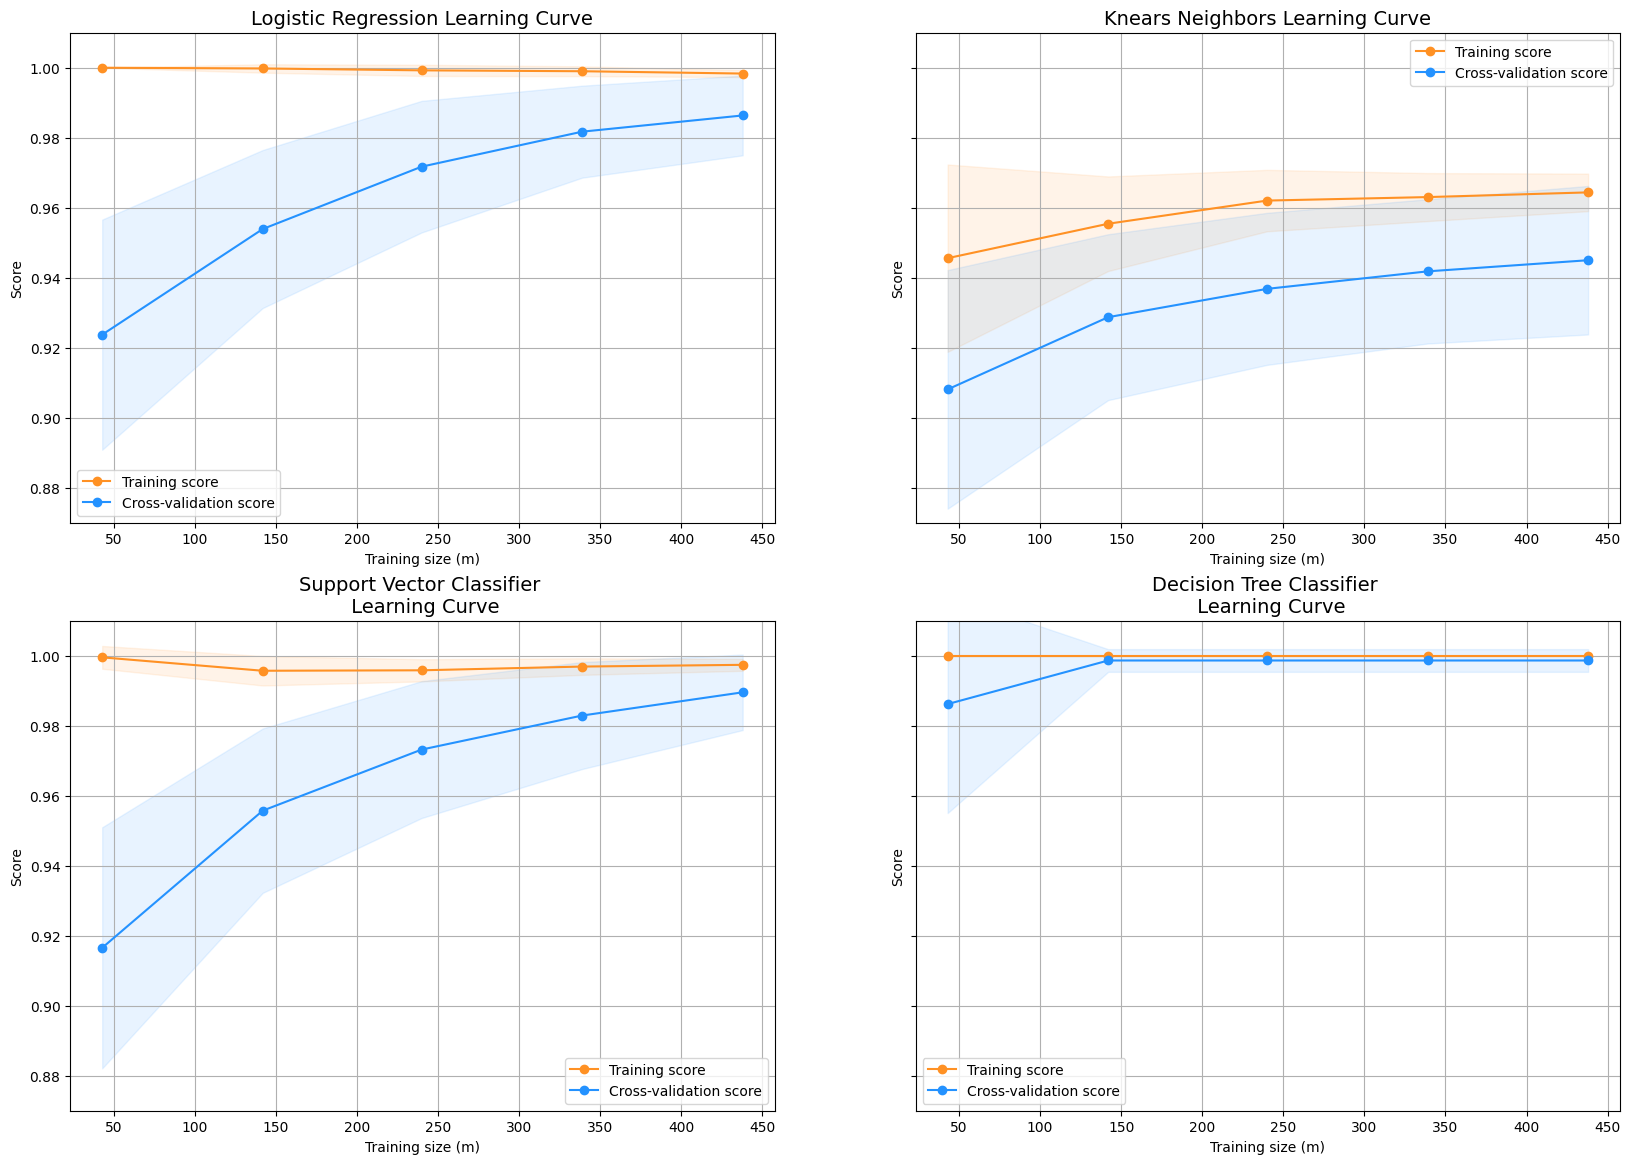

In [67]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv=cv, n_jobs=4)

In [68]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict

In [69]:
log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5, method="decision_function")
knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)
svc_pred = cross_val_predict(svc, X_train, y_train, cv=5, method="decision_function")
tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [70]:
log_reg_pred.shape

(548,)

In [71]:
y_train.shape, X_train.shape

((548,), (548, 30))

In [72]:
print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9966678662348222
KNears Neighbors:  0.949624801738041
Support Vector Classifier:  0.9964412811387902
Decision Tree Classifier:  0.99812734082397


In [73]:
import xgboost as xgb

In [74]:
X_train.shape, X_test.shape

((548, 30), (137, 30))

In [75]:
y_res.value_counts()

,count
Class,
0,199008
1,199008


#Now let's try SMOTE technique

In [76]:
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [200, 500]
}

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    seed=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_res, y_res)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:27:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [200, 500], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [77]:
y_val_real.value_counts()

,count
Class,
0,59705
1,105


In [78]:
best_params_from_grid = grid_search.best_params_
params = {
    "objective": "binary:logistic",
    "max_depth": best_params_from_grid['max_depth'],
    "learning_rate": best_params_from_grid['learning_rate'],
    "subsample": best_params_from_grid['subsample'],
    "colsample_bytree": best_params_from_grid['colsample_bytree'],
    "min_child_weight": 5,
    "gamma": 2,
    "eval_metric": "logloss",
    "seed": 42,
    "reg_alpha": 8,
    "reg_lambda": 8,
}

dtrain = xgb.DMatrix(X_res, y_res)  # X_train_u, label=y_train_u
dval   = xgb.DMatrix(X_val_real, label=y_val_real)
evals_result = {}
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=400,
    evals=[(dtrain, "train"), (dval, "valid")],
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=True
)


[0]	train-logloss:0.61065	valid-logloss:0.61060
[1]	train-logloss:0.54305	valid-logloss:0.54264
[2]	train-logloss:0.48658	valid-logloss:0.48555
[3]	train-logloss:0.43875	valid-logloss:0.43702
[4]	train-logloss:0.39731	valid-logloss:0.39485
[5]	train-logloss:0.36169	valid-logloss:0.35859
[6]	train-logloss:0.33081	valid-logloss:0.32706
[7]	train-logloss:0.30300	valid-logloss:0.29869
[8]	train-logloss:0.27913	valid-logloss:0.27414
[9]	train-logloss:0.25775	valid-logloss:0.25237
[10]	train-logloss:0.23909	valid-logloss:0.23311
[11]	train-logloss:0.22227	valid-logloss:0.21602
[12]	train-logloss:0.20748	valid-logloss:0.20091
[13]	train-logloss:0.19381	valid-logloss:0.18706
[14]	train-logloss:0.18183	valid-logloss:0.17496
[15]	train-logloss:0.17086	valid-logloss:0.16388
[16]	train-logloss:0.16097	valid-logloss:0.15385
[17]	train-logloss:0.15215	valid-logloss:0.14499
[18]	train-logloss:0.14412	valid-logloss:0.13689
[19]	train-logloss:0.13707	valid-logloss:0.12972
[20]	train-logloss:0.12937	val

In [79]:
best_rf = grid_search.best_estimator_
best_score = cross_val_score(best_rf, X_res, y_res, cv=5) # na zbiorze treningowym żeby ocenić stabilność modelu
print(f'{round(best_score.mean(), 2) * 100} %')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:28:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:28:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:29:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:29:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:29:45] WARNING: /w

100.0 %


In [80]:
xgb_ = best_rf.predict_proba(X_test_real)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_real, xgb_)
pr_auc = average_precision_score(y_test_real, xgb_)
pr_auc


np.float64(0.8900811366128064)

In [81]:
X_test_u = xgb.DMatrix(X_test_real)
xgb_preds_u = model.predict(X_test_u)
xgb_preds_u = tf.round(xgb_preds_u)
xgb_preds_u

<tf.Tensor: shape=(25633,), dtype=float32, numpy=array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)>

In [82]:
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(y_test_real, xgb_preds_u)
print("Balanced Accuracy:", bal_acc)

Balanced Accuracy: 0.9508903034289156


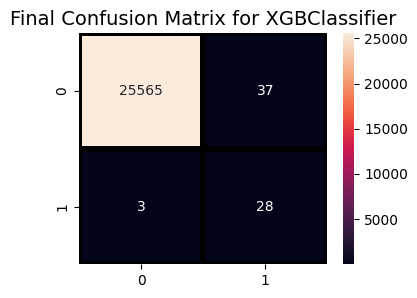

In [83]:
X_test_m = xgb.DMatrix(X_test_real)
xgb_preds_u = model.predict(X_test_m)
xgb_preds_u = tf.round(xgb_preds_u)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test_real, xgb_preds_u), annot=True, fmt= "d", linecolor="k", linewidths=3)
plt.title("Final Confusion Matrix for XGBClassifier",fontsize=14)
plt.show()


In [84]:
confusion_matrix(y_test_real, xgb_preds_u)

array([[25565,    37],
       [    3,    28]])

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, average_precision_score

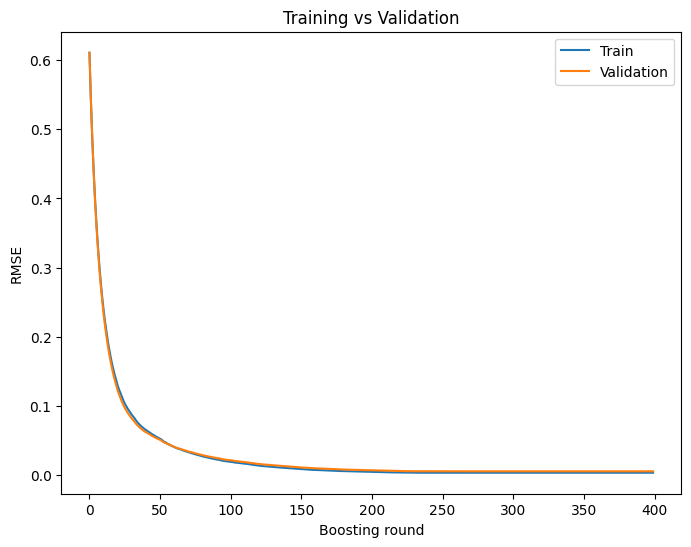

In [86]:
plt.figure(figsize=(8,6))
plt.plot(evals_result['train']['logloss'], label='Train')
plt.plot(evals_result['valid']['logloss'], label='Validation')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('Training vs Validation')
plt.legend()
plt.show()

# Now we try to use weighted balanced set in algorith

In [87]:
ratio = int(sum(y_train_real == 0) / sum(y_train_real == 1))

In [88]:
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=ratio,
    seed=42,
    use_label_encoder=True
)

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'n_estimators': [200, 400]

}

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='average_precision',
    cv=3,
    verbose=2,
    n_jobs=-1
)
grid.fit(X_train_real, y_train_real)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:39:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='aucpr', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [200, 400], 'subsample': [0.8, 1]},
             scoring='average_precision', verbose=2)

In [89]:
best_params_from_grid = grid.best_params_
params = {
    "objective": "binary:logistic",
    "max_depth": best_params_from_grid['max_depth'],
    "learning_rate": best_params_from_grid['learning_rate'],
    "subsample": best_params_from_grid['subsample'],
    "colsample_bytree": best_params_from_grid['colsample_bytree'],
    "n_estimators": best_params_from_grid['n_estimators'],
    "min_child_weight": 5,
    "gamma": 2,
    "eval_metric": "aucpr",
    "seed": 42,
    "reg_alpha": 5,
    "reg_lambda": 5
}

dtrain = xgb.DMatrix(X_train_real, label=y_train_real)  # X_train_u, label=y_train_u
dval   = xgb.DMatrix(X_val_real, label=y_val_real)
evals_result = {}
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=400,
    evals=[(dtrain, "train"), (dval, "valid")],
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=True
)


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [17:40:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-aucpr:0.06901	valid-aucpr:0.06807
[1]	train-aucpr:0.63388	valid-aucpr:0.61406
[2]	train-aucpr:0.71285	valid-aucpr:0.70574
[3]	train-aucpr:0.72899	valid-aucpr:0.71928
[4]	train-aucpr:0.72600	valid-aucpr:0.72934
[5]	train-aucpr:0.72837	valid-aucpr:0.73122
[6]	train-aucpr:0.76194	valid-aucpr:0.75125
[7]	train-aucpr:0.76420	valid-aucpr:0.75429
[8]	train-aucpr:0.76503	valid-aucpr:0.75515
[9]	train-aucpr:0.77055	valid-aucpr:0.75607
[10]	train-aucpr:0.77156	valid-aucpr:0.75814
[11]	train-aucpr:0.77215	valid-aucpr:0.75818
[12]	train-aucpr:0.77252	valid-aucpr:0.76006
[13]	train-aucpr:0.78935	valid-aucpr:0.81241
[14]	train-aucpr:0.79032	valid-aucpr:0.81003
[15]	train-aucpr:0.78885	valid-aucpr:0.80724
[16]	train-aucpr:0.79578	valid-aucpr:0.80651
[17]	train-aucpr:0.79725	valid-aucpr:0.80593
[18]	train-aucpr:0.80037	valid-aucpr:0.80938
[19]	train-aucpr:0.80557	valid-aucpr:0.80858
[20]	train-aucpr:0.81200	valid-aucpr:0.82166
[21]	train-aucpr:0.81239	valid-aucpr:0.82657
[22]	train-aucpr:0.8

In [90]:
best_rf = grid.best_estimator_
best_score = cross_val_score(best_rf, X_train_real, y_train_real, cv=5) # na zbiorze treningowym żeby ocenić stabilność modelu
print(f'{round(best_score.mean(), 2) * 100} %')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:40:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:40:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:40:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:40:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:40:54] WARNING: /w

100.0 %


In [91]:
xgb_ = best_rf.predict_proba(X_test_real)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_real, xgb_)
pr_auc = average_precision_score(y_test_real, xgb_)
pr_auc


np.float64(0.9117697080929194)

In [92]:
X_test_u = xgb.DMatrix(X_test_real)
xgb_preds_u = model.predict(X_test_u)
xgb_preds_u = tf.round(xgb_preds_u)
xgb_preds_u


<tf.Tensor: shape=(25633,), dtype=float32, numpy=array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)>

In [93]:
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(y_test_real, xgb_preds_u)
print("Balanced Accuracy:", bal_acc)

Balanced Accuracy: 0.9192962495369565


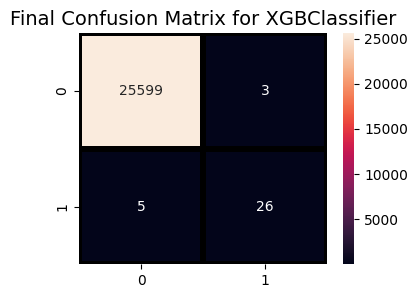

In [94]:
X_test_m = xgb.DMatrix(X_test_real)
xgb_preds_u = model.predict(X_test_m)
xgb_preds_u = tf.round(xgb_preds_u)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test_real, xgb_preds_u), annot=True, fmt= "d", linecolor="k", linewidths=3)
plt.title("Final Confusion Matrix for XGBClassifier",fontsize=14)
plt.show()


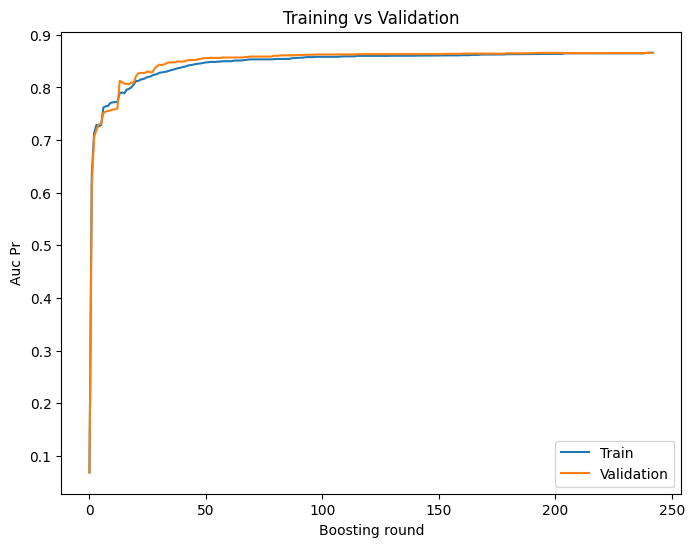

In [95]:
plt.figure(figsize=(8,6))
plt.plot(evals_result['train']['aucpr'], label='Train')
plt.plot(evals_result['valid']['aucpr'], label='Validation')
plt.xlabel('Boosting round')
plt.ylabel('Auc Pr')
plt.title('Training vs Validation')
plt.legend()
plt.show()

In [96]:

X_val_m = xgb.DMatrix(X_val_real)
xgb_preds_val =  model.predict(X_val_m)
xgb_preds_val =  tf.round(xgb_preds_val)

In [97]:
confusion_matrix(y_val_real, xgb_preds_val)

array([[59697,     8],
       [   22,    83]])

In [98]:
confusion_matrix(y_test_real, xgb_preds_u)

array([[25599,     3],
       [    5,    26]])

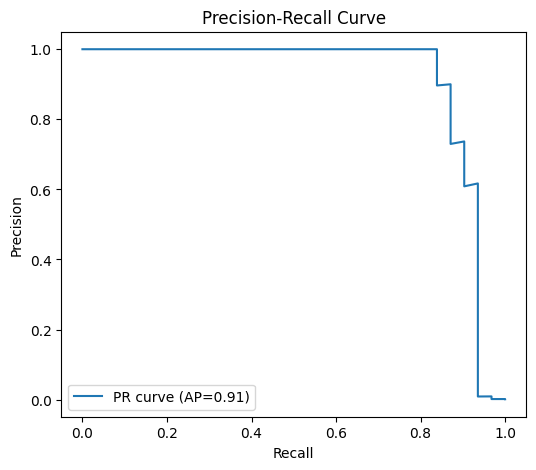

In [99]:
# prawdopodobieństwa dla klasy 1
y_scores = best_rf.predict_proba(X_test_real)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_real, y_scores)
ap = average_precision_score(y_test_real, y_scores)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR curve (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# maximize F1 (symmetrically precision and recall)

In [100]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
proba = best_rf.predict_proba(X_val_real)[:,1]
prec, rec, thr = precision_recall_curve(y_val_real, proba)
f1 = 2 * prec * rec / (prec+rec+1e-12) # 1e-12 żeby nie dzielić przez 0
ix = np.nanargmax(f1) # ignoruj nan-y
best_thr_f1 = thr[ix-1]  # uwaga: thr ma o 1 mniej elementów niż prec/rec bo poczatkowy punkt krzywej nie ma przypisanego odpowiednika thresholda dlatego zawsze -1
print("Best F1:", f1[ix], "threshold:", best_thr_f1)


Best F1: 0.8944723618085466 threshold: 0.49000412


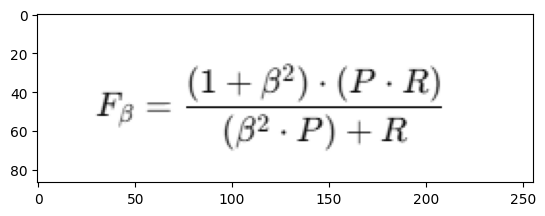

In [102]:
img = plt.imread('beta.png')
plt.imshow(img)

- dla β=1 → F1 (równowaga P i R),
- dla β=2 → recall waży 4x mocniej niż precision,
- dla β=0.5 → precision waży 4x mocniej niż recall.

- P = precision (ile z moich „fraudów” to faktycznie fraudy),
- R = recall (ile procent prawdziwych fraudów złapałem).

# When Recall is more important than precission

In [103]:
beta = 0.2 # recall more important
fbeta = (1+beta**2)*(prec*rec)/(beta**2*prec + rec + 1e-12)
ix = np.nanargmax(fbeta)
best_thr_f2 = thr[ix-1]
print("Best F2:", fbeta[ix], "threshold:", best_thr_f2)

Best F2: 0.9819148936156503 threshold: 0.99961


# When we set a responsible threshold for precission at maximum recall

In [104]:
mask = prec[:-1] >= 0.70   # pomijamy ostatni punkt bez progu
if mask.any():
    cand_ix = np.where(mask)[0] # indexy z precission >= 0.7
    ix = cand_ix[np.argmax(rec[cand_ix])]  # indeksy dodatkowo z maxymalnym recall
    thr70 = thr[ix-1]
    print("Max recall przy precision≥0.70:", rec[ix], "threshold:", thr70)

Max recall przy precision≥0.70: 0.9142857142857143 threshold: 0.0095648


In [105]:
print('walidacyjna')
y_pred = (proba >= best_thr_f1).astype(int)   # lub thr70 / best_thr_f2
print(confusion_matrix(y_val_real, y_pred))
print(classification_report(y_val_real, y_pred, digits=3))
print('----------------------------------------------------')
print('testowa')
proba2 = best_rf.predict_proba(X_test_real)[:,1]
y_pred_2 = (proba2 >= best_thr_f1).astype(int)
print(confusion_matrix(y_test_real, y_pred_2))

walidacyjna
[[59699     6]
 [   16    89]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     59705
           1      0.937     0.848     0.890       105

    accuracy                          1.000     59810
   macro avg      0.968     0.924     0.945     59810
weighted avg      1.000     1.000     1.000     59810

----------------------------------------------------
testowa
[[25598     4]
 [    4    27]]


In [106]:
print('walidacyjna 2')
y_pred_2 = (proba >= thr70).astype(int)   # lub thr70 / best_thr_f2
print(confusion_matrix(y_val_real, y_pred_2))
print(classification_report(y_val_real, y_pred_2, digits=3))
print('----------------------------------------------------')
print('testowa 2')
proba3 = best_rf.predict_proba(X_test_real)[:,1]
y_pred_2 = (proba3 >= thr70).astype(int)
print(confusion_matrix(y_test_real, y_pred_2))

walidacyjna 2
[[59663    42]
 [    9    96]]
              precision    recall  f1-score   support

           0      1.000     0.999     1.000     59705
           1      0.696     0.914     0.790       105

    accuracy                          0.999     59810
   macro avg      0.848     0.957     0.895     59810
weighted avg      0.999     0.999     0.999     59810

----------------------------------------------------
testowa 2
[[25577    25]
 [    2    29]]


In [107]:
print('walidacyjna 3')
y_pred_3 = (proba >= best_thr_f2).astype(int)   # lub thr70 / best_thr_f2
print(confusion_matrix(y_val_real, y_pred_3))
print(classification_report(y_val_real, y_pred_3, digits=3))
print('----------------------------------------------------')
print('testowa 3')
proba4 = best_rf.predict_proba(X_test_real)[:,1]
y_pred_2 = (proba4 >= best_thr_f2).astype(int)
print(confusion_matrix(y_test_real, y_pred_2))

walidacyjna 3
[[59704     1]
 [   34    71]]
              precision    recall  f1-score   support

           0      0.999     1.000     1.000     59705
           1      0.986     0.676     0.802       105

    accuracy                          0.999     59810
   macro avg      0.993     0.838     0.901     59810
weighted avg      0.999     0.999     0.999     59810

----------------------------------------------------
testowa 3
[[25602     0]
 [    9    22]]


# RandomForestClassifier

In [113]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

#param_grid = {
#   'n_estimators':[200, 500],
#   'max_depth': [None, 20],
#   'min_samples_split': [2, 10],
#   'min_samples_leaf': [1, 5],
#   'max_features': ['sqrt', 'log2']
#}
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 7],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ['sqrt', 'log2']
}

In [109]:
np.arange(2, 10)

array([2, 3, 4, 5, 6, 7, 8, 9])

In [114]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#grid_search = GridSearchCV(
#    estimator=rf,
#    param_grid=param_grid,
#    scoring='average_precision',
#    cv=cv,
#    verbose=2,
#    n_jobs=-1
#)
grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                     # ile kombinacji próbujemy
    scoring="average_precision",   # metryka dopasowana do fraudów
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
# trenowanie
grid_search.fit(X_train_real, y_train_real)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [2, 4],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='average_precision', verbose=2)

In [110]:
X_train_real.shape

(199364, 30)

In [115]:
best_rf_forest = grid_search.best_estimator_

In [116]:
best_score = cross_val_score(best_rf_forest, X_train_real, y_train_real, cv=5) # na zbiorze treningowym żeby ocenić stabilność modelu
print(f'{round(best_score.mean(), 2) * 100} %')

100.0 %


In [117]:
##
forest_ = best_rf_forest.predict_proba(X_test_real)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_real, forest_)
pr_auc = average_precision_score(y_test_real, forest_)
pr_auc
###

np.float64(0.9039943627729268)

In [118]:
X_test_forest = xgb.DMatrix(X_test_real)
forest_preds_u = model.predict(X_test_forest)
forest_preds_u = tf.round(forest_preds_u)
forest_preds_u

<tf.Tensor: shape=(25633,), dtype=float32, numpy=array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)>

In [119]:
###
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(y_test_real, forest_preds_u)
print("Balanced Accuracy:", bal_acc)
####

Balanced Accuracy: 0.9192962495369565


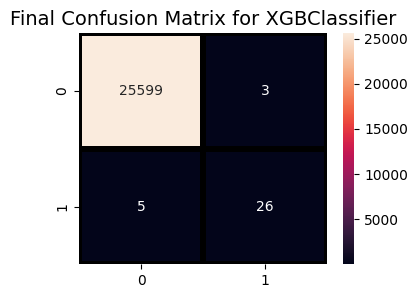

array([[25599,     3],
       [    5,    26]])

In [120]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test_real, forest_preds_u), annot=True, fmt= "d", linecolor="k", linewidths=3)
plt.title("Final Confusion Matrix for XGBClassifier",fontsize=14)
plt.show()
###
confusion_matrix(y_test_real, forest_preds_u)

In [122]:
y_train_real.value_counts()

,count
Class,
0,199008
1,356


# We consider LogisticRegression, SVM, DecissionTree but at this time on balanced data and see if the results will improve

In [123]:
log_reg_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
grid_log_reg = GridSearchCV(
    LogisticRegression(class_weight="balanced", solver="saga"),  # balanced + solver
    log_reg_params,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)
grid_log_reg.fit(X_train_real, y_train_real)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=3,
             estimator=LogisticRegression(class_weight='balanced',
                                          solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']},
             scoring='average_precision')

In [128]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svc_params = {'C': [0.5, 1, 2]}
grid_svc = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42),
    svc_params,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)
grid_svc.fit(X_train_real, y_train_real)


GridSearchCV(cv=3,
             estimator=LinearSVC(class_weight='balanced', random_state=42),
             n_jobs=-1, param_grid={'C': [0.5, 1, 2]},
             scoring='average_precision')

In [129]:
tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3],
    "min_samples_leaf": [5, 6]
}
grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    tree_params,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)
grid_tree.fit(X_train_real, y_train_real)

GridSearchCV(cv=3,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'], 'max_depth': [2, 3],
                         'min_samples_leaf': [5, 6]},
             scoring='average_precision')

In [130]:
best_log_ = grid_log_reg.best_estimator_
best_svc_ = grid_svc.best_estimator_
best_tree_ =  grid_tree.best_estimator_

In [131]:
reg_ = best_log_.predict_proba(X_test_real)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_real,reg_)
pr_auc = average_precision_score(y_test_real,reg_)
pr_auc

np.float64(0.7830287033703333)

In [133]:
y_scores_svc = best_svc_.decision_function(X_test_real)
# average precision (PR-AUC)
pr_auc = average_precision_score(y_test_real, y_scores_svc)
pr_auc

np.float64(0.7967187947435252)

In [134]:
grid_ = best_tree_.predict_proba(X_test_real)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_real, grid_)
pr_auc = average_precision_score(y_test_real, grid_)
pr_auc

np.float64(0.5959169681395158)

In [136]:
#X_test_reg = xgb.DMatrix(X_test_real)
reg_preds_u = best_log_.predict(X_test_real)
reg_preds_u = tf.round(reg_preds_u)
reg_preds_u

<tf.Tensor: shape=(25633,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>

In [137]:
#X_test_svc = xgb.DMatrix(X_test_real)
svc_preds_u = best_svc_.predict(X_test_real)
svc_preds_u = tf.round(svc_preds_u)
svc_preds_u

<tf.Tensor: shape=(25633,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>

In [138]:
#X_test_tree = xgb.DMatrix(X_test_real)
tree_preds_u = best_tree_.predict(X_test_real)
tree_preds_u = tf.round(tree_preds_u)
tree_preds_u

<tf.Tensor: shape=(25633,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 1, 0])>

In [140]:
print(confusion_matrix(y_test_real, reg_preds_u))
print('---------------------------------------')
print(confusion_matrix(y_test_real, svc_preds_u))
print('---------------------------------------')
print(confusion_matrix(y_test_real, tree_preds_u))

[[25013   589]
 [    2    29]]
---------------------------------------
[[25156   446]
 [    2    29]]
---------------------------------------
[[24354  1248]
 [    2    29]]


In [ ]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)
def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve \n Top 4 Classifiers', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.legend()
graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

In [ ]:
def logistic_roc_curve(log_fpr, log_tpr):
    plt.figure(figsize=(12,8))
    plt.title('Logistic Regression ROC Curve', fontsize=16)
    plt.plot(log_fpr, log_tpr, 'b-', linewidth=2)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.axis([-0.01,1,0,1])

logistic_roc_curve(log_fpr, log_tpr)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
y_pred = log_reg.predict(X_train)

# Overfitting Case
print('---' * 45)
print('Recall Score: {:.2f}'.format(recall_score(y_train, y_pred)))
print('Precision Score: {:.2f}'.format(precision_score(y_train, y_pred)))
print('F1 Score: {:.2f}'.format(f1_score(y_train, y_pred)))
print('Accuracy Score: {:.2f}'.format(accuracy_score(y_train, y_pred)))
print('---' * 45)
